In [70]:
import numpy as np
import sklearn
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

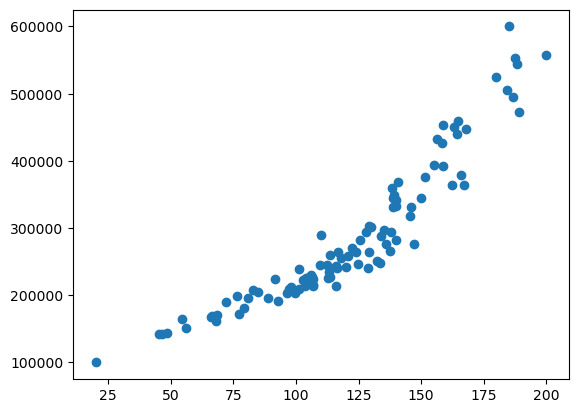

In [90]:
x,y=make_regression(n_samples=100,n_features=1,noise=10,random_state=42)
x_min, x_max = 30, 250
x_plot = np.interp(x, (x.min(), x.max()), (x_min, x_max))

y=y+abs(y/2)
y_min, y_max = 100_000, 600_000
y_plot = np.interp(y, (y.min(), y.max()), (y_min, y_max))

plt.scatter(x_plot,y_plot)

In [80]:
print (x.shape)
y=y.reshape(y.shape[0],1)
print(y.shape)


(100, 1)
(100, 1)


In [81]:
#matrice X
X=np.hstack((x,np.ones(x.shape)))
X=np.hstack((x**2,X))
X

array([[ 8.67282660e-01,  9.31280119e-01,  1.00000000e+00],
       [ 7.57719209e-03,  8.70470682e-02,  1.00000000e+00],
       [ 1.11875241e+00, -1.05771093e+00,  1.00000000e+00],
       [ 9.87513860e-02,  3.14247333e-01,  1.00000000e+00],
       [ 2.29607950e-01, -4.79174238e-01,  1.00000000e+00],
       [ 4.19500442e-01,  6.47688538e-01,  1.00000000e+00],
       [ 2.14755958e-01, -4.63417693e-01,  1.00000000e+00],
       [ 2.94371401e-01,  5.42560044e-01,  1.00000000e+00],
       [ 3.74147882e-01,  6.11676289e-01,  1.00000000e+00],
       [ 1.00707828e+00,  1.00353290e+00,  1.00000000e+00],
       [ 6.75523727e-01,  8.21902504e-01,  1.00000000e+00],
       [ 2.36555648e+00,  1.53803657e+00,  1.00000000e+00],
       [ 5.45332890e-01,  7.38466580e-01,  1.00000000e+00],
       [ 4.82557383e-02, -2.19671888e-01,  1.00000000e+00],
       [ 6.53661906e-01, -8.08493603e-01,  1.00000000e+00],
       [ 8.42004011e-03,  9.17607765e-02,  1.00000000e+00],
       [ 3.84030699e+00, -1.95967012e+00

In [56]:
theta=np.random.randn(3,1)
theta

array([[ 0.8476958 ],
       [-1.60699131],
       [-1.31596585]])

In [57]:
def model (X,theta):
    return X.dot(theta)

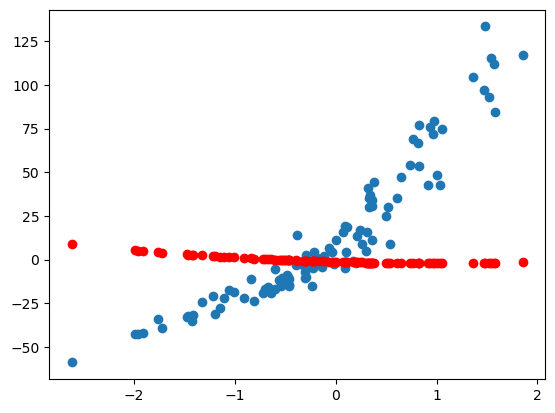

In [82]:
plt.scatter (x,y)
plt.scatter(x,model(X,theta), c='r')

# Fonction cout


In [74]:
def cost_function (X,y,theta):
    m=len(y)
    return 1/(2*m) * np.sum((model(X,theta)-y)**2)

In [60]:
cost_function(X,y,theta)

np.float64(987.116730106195)

# Gradient

In [75]:
def gradient(X,y,theta):
    m=len(y)
    return 1/m * X.T.dot(model(X,theta)-y)

# Gradient descent

In [76]:
def gradiant_descent( X,y,theta, rate, n_iterations):
    cost_history=np.zeros(n_iterations)
    i = 0
    while i < n_iterations:
        theta=theta- rate*gradient(X,y,theta)  
        cost_history[i]=cost_function(X,y,theta)
        i = i + 1
    return theta,cost_history
    

## Execution

In [83]:
theta_final,cost_history =gradiant_descent(X,y,theta, rate=0.01,n_iterations=1000)


In [64]:
theta_final

array([[10.24188029],
       [45.74217857],
       [ 9.15919398]])

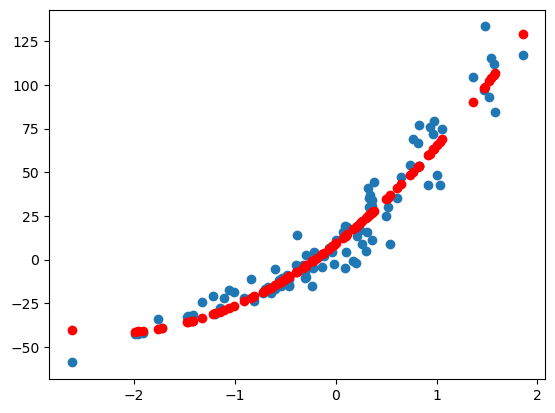

In [88]:
predictions=model(X,theta_final)
plt.scatter (x,y)
plt.scatter(x,predictions, c='r')

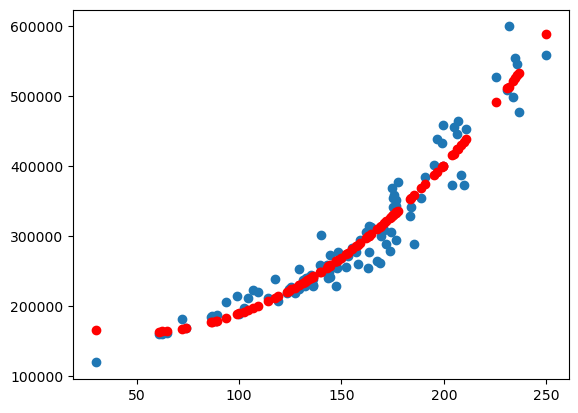

In [89]:
predictions=model(X,theta_final)
x_plot = np.interp(x, (x.min(), x.max()), (30, 250))      # Surface terrain
y_plot = np.interp(y, (y.min(), y.max()), (120_000, 600_000))  # Prix maison
predictions_plot=np.interp(predictions, (y.min(), y.max()), (120_000, 600_000))  # Prix maison
plt.scatter (x_plot,y_plot)
plt.scatter(x_plot,predictions_plot, c='r')

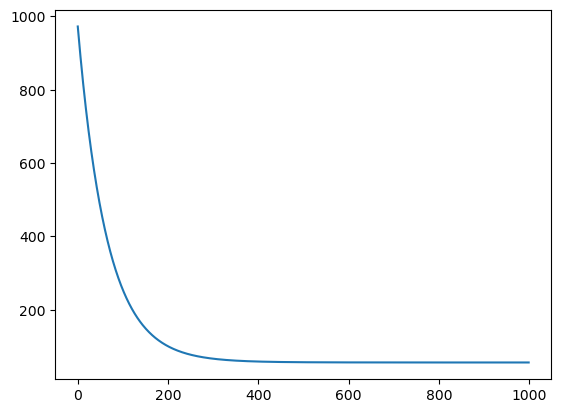

In [66]:
plt.plot(range(1000),cost_history)

## Coeff determination

In [67]:
def coef_determination(y,pred):
    u=((y-pred)**2).sum()
    v=((y -np.mean(y))**2).sum()
    return 1 - u/v
       
       
    

In [68]:
print(coef_determination(y,predictions))


0.932994769829942
